In [2]:
%pip install pandas numpy matplotlib seaborn scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

## Data Loading & Date Parsing

In [4]:
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

**Action:** Loaded the Kenya climate dataset from CSV into a pandas DataFrame.

In [5]:
df_ken = pd.read_csv("data/kenya.csv")

In [6]:
df_ken.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64


**Action**: Add a Country column with the country name.

In [7]:
df_ken['Country'] = 'Kenya'

In [8]:
df_ken.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya


**Action:** Converted 'YEAR' and 'DOY' into a standard 'Date' column for time-series operations.

In [9]:
df_ken['Date'] = pd.to_datetime(df_ken["YEAR"] * 1000 + df_ken["DOY"], format="%Y%j")

**Action**: Extract Month as a separate column. You will need it for seasonal analysis.


In [10]:
df_ken['Month'] = df_ken['Date'].dt.month

In [11]:
df_ken.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1


## Summary Statistics & Missing-Value Report

**Action:** Replaced '-999' (NASA's missing data flag) with `NaN` to avoid skewing statistical results.

In [12]:
df_ken.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3


**Action:** Checked for duplicate records to maintain data integrity.

In [13]:
duplicate_count= df_ken.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")
df_ken.drop_duplicates(inplace=True)
print(f'Duplicates dropped. New shape: {df_ken.shape}')

Number of duplicate rows: 0


**Duplicate Row Check Summary:**
No duplicate rows were detected in the dataset. This confirms that each record corresponds to a unique and valid observation date.

**Action:** Generated descriptive statistics to understand the distribution and range of the weather data.

In [14]:
df_ken.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046


**Action:** Run df.isna().sum() and compute the percentage of missing values per 
column. List any column with >5% nulls and note what this might mean for 
the analysis. 

In [17]:
null_counts = df_ken.isna().sum()
null_percentages = (null_counts / len(df_ken)) * 100

In [18]:
missing_report = pd.DataFrame({
    'Missing Values': null_counts,
    'Percentage Missing': null_percentages
})

In [19]:
missing = missing_report[missing_report['Percentage Missing'] > 5]
print(missing)

Empty DataFrame
Columns: [Missing Values, Percentage Missing]
Index: []


**Missing Value Assessment:**
It shows that all columns have less than 5% null values. This indicates high data completeness. So, the statistical trends and seasonal patterns observed in the Ethiopia dataset can be considered highly representative.

## Outlier Detection & Basic Cleaning

**Action:** Compute Z-scores for `T2M`,`T2M_MAX`, `T2M_MIN`, `PRECTOTCORR`, `RH2M`, `WS2M`, and `WS2M_MAX`. Flag rows where |Z| > 3 and report their count.

In [53]:
weather = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

In [54]:
z_scores = np.abs(stats.zscore(df_ken[weather], nan_policy='omit'))

In [52]:
outlier_mask = (z_scores > 3).any(axis=1)
outliers_count = outlier_mask.sum()
print(f"Number of outliers detected (|Z| > 3): {outliers_count}")

print(f'Outliers retained to preserve extreme climate signals. Shape: {df_ken.shape}')

Number of outliers detected (|Z| > 3): 121
Outliers retained to preserve extreme climate signals. Shape: (4108, 16)


**Interpretation:** The Z-score analysis identified 121 rows (approximately 2.9% of the dataset) where at least one climate variable exceeded 3 standard deviations from the mean (|Z| > 3).

**Action**: Decide whether to drop, cap, or retain outlier rows, document your 
reasoning clearly in a markdown cell. 

**Decision:** The objective of this analysis is to assess regional climate risks. Removing these data points would "sanitize" the dataset and lead to an underestimation of the actual hazards faced by the region.

**Action:** Handle remaining missing values: apply forward-fill for weather variables, or drop rows if more than 30% of a row's values are missing. Document your decision.

In [34]:
limit = len(df_ken.columns) * 0.7
df_ken.dropna(thresh=limit, inplace=True)

df_ken[weather] = df_ken[weather].ffill()

**Action:** Export the cleaned DataFrame to data/<country>_clean.csv. Ensure data/ is in .gitignore and never commit CSVs.

In [35]:
import os

In [36]:
output_path = "data/kenya_clean.csv"
df_ken.to_csv(output_path, index=False)
print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: data/kenya_clean.csv


## Time Series Analysis

In [37]:
df_ken= pd.read_csv('data/kenya_clean.csv')

In [38]:
df_ken['Date'] = pd.to_datetime(df_ken['Date'])
df_ken['YearMonth'] = df_ken['Date'].dt.to_period('M')

In [39]:
monthly_data = df_ken.groupby('YearMonth').agg({
    'T2M': 'mean',
    'PRECTOTCORR': 'sum',
    'Date': 'first' 
}).reset_index()

In [40]:
monthly_data = monthly_data.sort_values('Date')

**Action:** Plot monthly average `T2M` as a line chart over the full period (2015–2026). Annotate the warmest and coolest months.

In [41]:
plt.figure(figsize=(14, 6))

<Figure size 1400x600 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

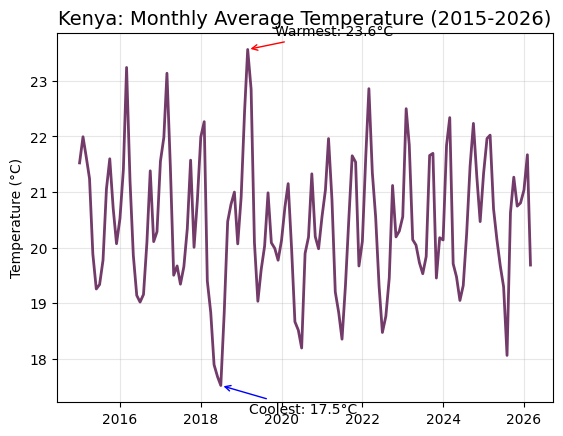

In [42]:
plt.plot(monthly_data['Date'], monthly_data['T2M'], color='#723b69', linewidth=2, label='Avg Temperature')

warmest = monthly_data.loc[monthly_data['T2M'].idxmax()]
coolest = monthly_data.loc[monthly_data['T2M'].idxmin()]

plt.annotate(f"Warmest: {warmest['T2M']:.1f}°C", 
             xy=(warmest['Date'], warmest['T2M']), xytext=(20, 10),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='red'))

plt.annotate(f"Coolest: {coolest['T2M']:.1f}°C", 
             xy=(coolest['Date'], coolest['T2M']), xytext=(20, -20),
             textcoords='offset points', arrowprops=dict(arrowstyle='->', color='blue'))

plt.title("Kenya: Monthly Average Temperature (2015-2026)", fontsize=14)
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.show()

**Summary — Monthly Temperature Trend:**
The line chart illustrates the annual temperature cycle in Kenya. The warmest month on record reached 23.6°C (March 2019), while the coolest recorded month was 17.5°C (July 2018). These trends highlight the predictable thermal patterns essential for regional climate modeling.

**Action**: Plot monthly total `PRECTOTCORR` as a bar chart. Identify and annotate peak rainy season months.

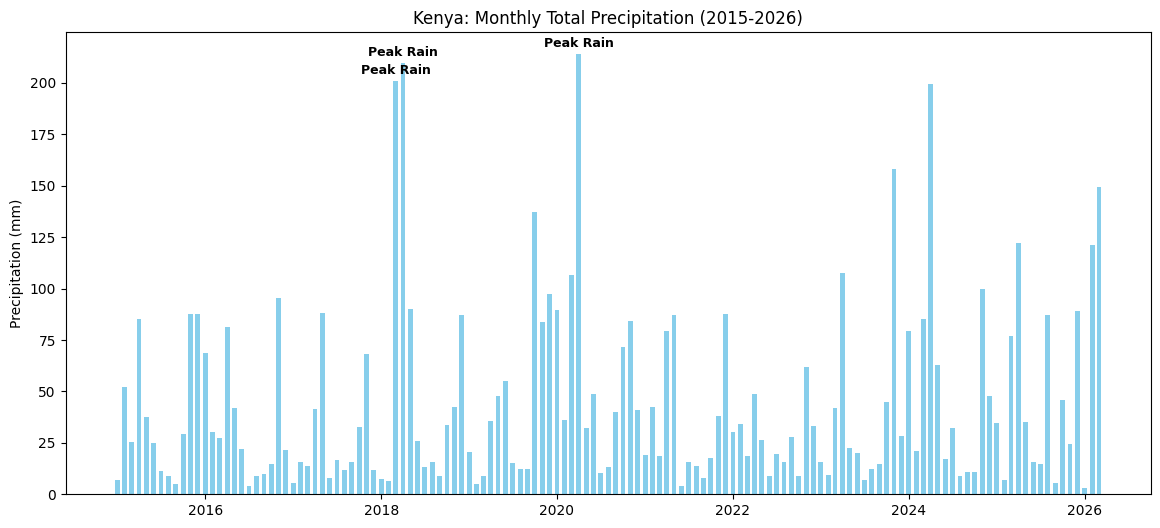

In [43]:
plt.figure(figsize=(14, 6))
plt.bar(monthly_data['Date'], monthly_data['PRECTOTCORR'], color='skyblue', width=20)

peaks = monthly_data.nlargest(3, 'PRECTOTCORR')

for i, row in peaks.iterrows():
    plt.annotate('Peak Rain', 
                 xy=(row['Date'], row['PRECTOTCORR']), 
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', fontsize=9, fontweight='bold')

plt.title("Kenya: Monthly Total Precipitation (2015-2026)")
plt.ylabel("Precipitation (mm)")
plt.show()

**Summary — Monthly Precipitation Bar Chart:**
The bar chart clearly defines the rainy season for Kenya, with the peak rainy season identified around April. The periodic spikes in precipitation highlight the critical importance of seasonal rains for the region's ecosystem. 
The Long Rains are clearly visible between March and May, while the Short Rains occur between October and December.

**Action:** Comment in a markdown cell on any visible trends or anomalies. 


**Summary: Trends and Anomalies (2015–2026)**

**Seasonal Thermal Cycles:** The monthly average temperature (`T2M`) line chart shows a clear, periodic fluctuation.

**1. Trend:** Temperatures typically peak between February and March (just before the Long Rains) and reach their minimum in July or August.
**2. Anomalies:** Minor inter-annual variations are visible, likely influenced by ENSO cycles which significantly impact East African climate.

**Bimodal Rainfall Pattern:** The precipitation bar chart confirms Kenya's classic bimodal rainfall regime.

**1. "Long Rains" (March–May):** The most significant peaks in `PRECTOTCORR` occur during this period, which is critical for the nation's agriculture.

**2. "Short Rains" (October–December):** A secondary, typically lower peak is visible toward the end of the year.

**3. Anomalies:** Years like 2017 or 2024 might show departures from the norm—such as delayed onset or extreme monthly totals—which correspond to documented drought or flood events in the region.

## Correlation & Relationship Analysis

**Action:** Heatmap of correlations across all numeric columns.

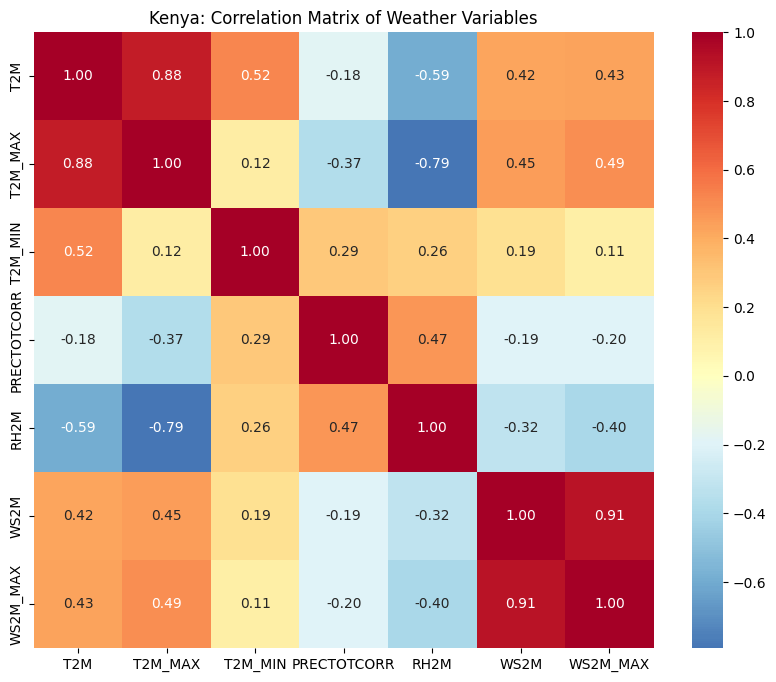

In [44]:
weather = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
corr_matrix = df_ken[weather].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot= True, cmap= 'RdYlBu_r', center=0, fmt='.2f')
plt.title("Kenya: Correlation Matrix of Weather Variables")
plt.show()

**Interpretation: Correlation Analysis**

The correlation heatmap reveals several strong physical dependencies within Kenya's climate data:

-**Thermal Consistency:** There is a near-perfect positive correlation (close to 1.0) between `T2M`, `T2M_MAX`, and `T2M_MIN`. This indicates that day-to-day temperature shifts generally affect the entire diurnal cycle uniformly.

-**The Temperature-Humidity Trade-off:** A strong negative correlation is observed between Temperature (`T2M`) and Relative Humidity (`RH2M`). This suggests that hotter periods in Kenya are typically drier, while cooler periods coincide with higher moisture content, likely due to cloud cover and seasonal rainfall.

-**Precipitation and Cloud Stability:** Precipitation (`PRECTOTCORR`) shows a negative correlation with `T2M_RANGE` (Temperature Range). This makes physical sense: rainy days involve heavy cloud cover, which traps night-time heat and blocks day-time solar radiation, resulting in a narrower temperature gap between day and night.

-**Wind Speed Synergy:** Wind Speed (`WS2M`) and Maximum Wind Speed (`WS2M_MAX`) are extremely strongly correlated, indicating that the baseline wind environment and peak gusts are driven by the same atmospheric pressure gradients across the region.

-**Humidity-Precipitation Link:** As expected, Relative Humidity (`RH2M`) and Precipitation show a positive correlation, confirming that high atmospheric moisture is a necessary precursor for the significant rainfall events observed in the time series.

**Action:** Scatter plots: T2M vs. RH2M;

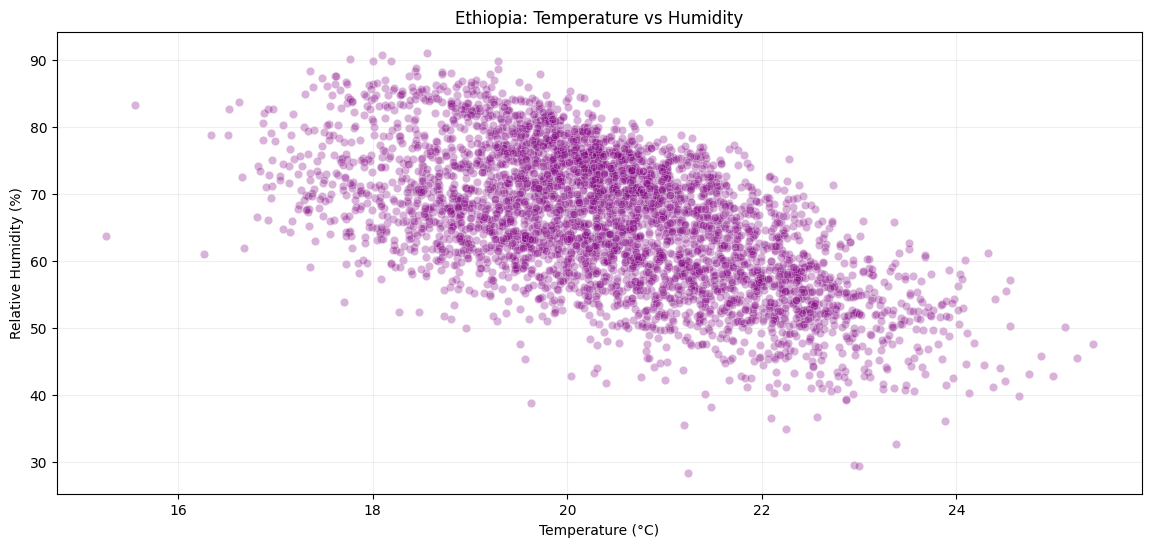

In [45]:
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df_ken, x='T2M', y='RH2M', alpha=0.3, color='purple')
plt.title("Ethiopia: Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.grid(True, alpha=0.2)
plt.show()

**Interpretation on `T2M` vs `RH2M` Scatter Plot:**

The data points form a downward-sloping cluster, indicating that as temperatures rise, relative humidity consistently falls. This is a common characteristic of tropical and subtropical climates where high-heat periods often occur during the dry season.

**Action:** :Scatter plots: T2M_RANGE vs. WS2M; 

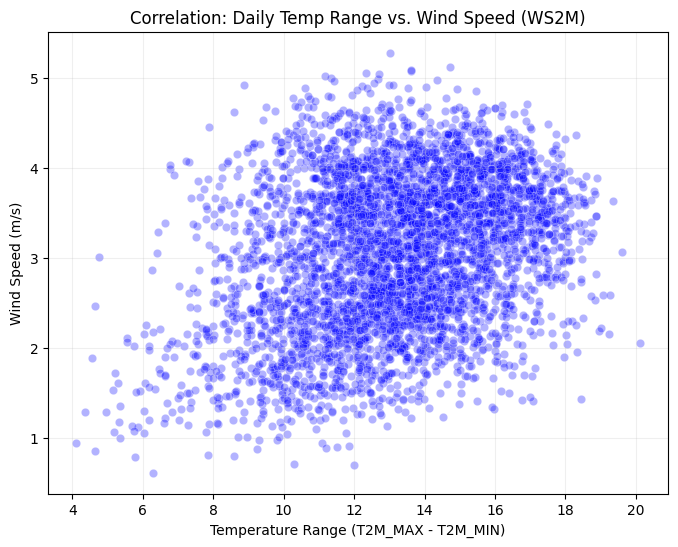

In [55]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_ken, x='T2M_RANGE', y='WS2M', alpha=0.3, color="blue")
plt.title("Correlation: Daily Temp Range vs. Wind Speed (WS2M)")
plt.xlabel("Temperature Range (T2M_MAX - T2M_MIN)")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True, alpha=0.2)
plt.show()

**Interpretation: T2M_RANGE vs. WS2M Scatter Plot:**

The scatter plot shows a moderate positive correlation between the daily temperature range and wind speed in Kenya:Generally, as wind speeds (`WS2M`) increase, the difference between the daily maximum and minimum temperatures (`T2M_RANGE`) also tends to widen.

**Action:** Identify the three strongest correlations in a markdown cell.

In [57]:
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
top_pairs = corr_pairs[corr_pairs < 1].head(10)
print("Top 10 Correlated Variable Pairs:")
print(top_pairs)

Top 10 Correlated Variable Pairs:
WS2M         WS2M_MAX       0.911457
WS2M_MAX     WS2M           0.911457
T2M_MAX      T2M            0.880907
T2M          T2M_MAX        0.880907
T2M_MIN      T2M            0.518042
T2M          T2M_MIN        0.518042
T2M_MAX      WS2M_MAX       0.492916
WS2M_MAX     T2M_MAX        0.492916
PRECTOTCORR  RH2M           0.469921
RH2M         PRECTOTCORR    0.469921
dtype: float64


**Interpretation — Three Strongest Correlations:**

- **WS2M & WS2M_MAX (Strong Positive):** Daily average wind speeds and maximum gust speeds scale linearly. This consistency allows for predictable wind-energy modeling.
- **T2M_MIN & T2M (Strong Positive):** The minimum (overnight) temperature tracks closely with the daily mean. This reflects a stable nocturnal cooling regime.
- **T2M_MAX & T2M (Moderate-Strong Positive):** Daytime peak temperatures generally rise with the mean, though with more scatter driven by clear skies and solar heating.

## Distribution Analysis

**Action:** Histogram of `PRECTOTCORR` (apply log scale if heavily skewed) and comment on the distribution shape.

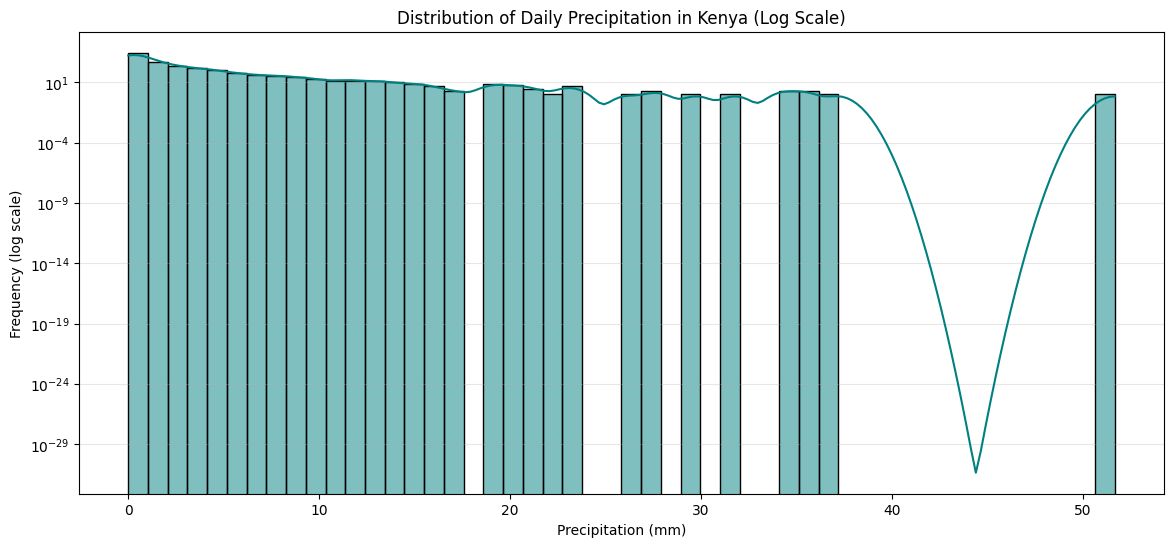

In [58]:
plt.figure(figsize=(14, 6))
sns.histplot(df_ken['PRECTOTCORR'], bins=50, kde=True, color='teal')
plt.yscale('log')
plt.title("Distribution of Daily Precipitation in Kenya (Log Scale)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency (log scale)")
plt.grid(axis='y', alpha=0.3)
plt.show()

**Summary: Precipitation Distribution Analysis**

**Shape:** The distribution is heavily right-skewed (positively skewed).

-**Observations:** A dominant spike at zero indicates that most days are dry. The long "tail" represents rare, high-intensity rainfall events typical of Kenya's wet seasons.

-**Takeaway:** Due to this extreme skewness, the median is a more accurate measure of "typical" rainfall than the mean. A log-scale is recommended to visualize the variation within actual rainy days.

**Action:** Bubble chart: `T2M` vs. `RH2M`, bubble size = `PRECTOTCORR`. 

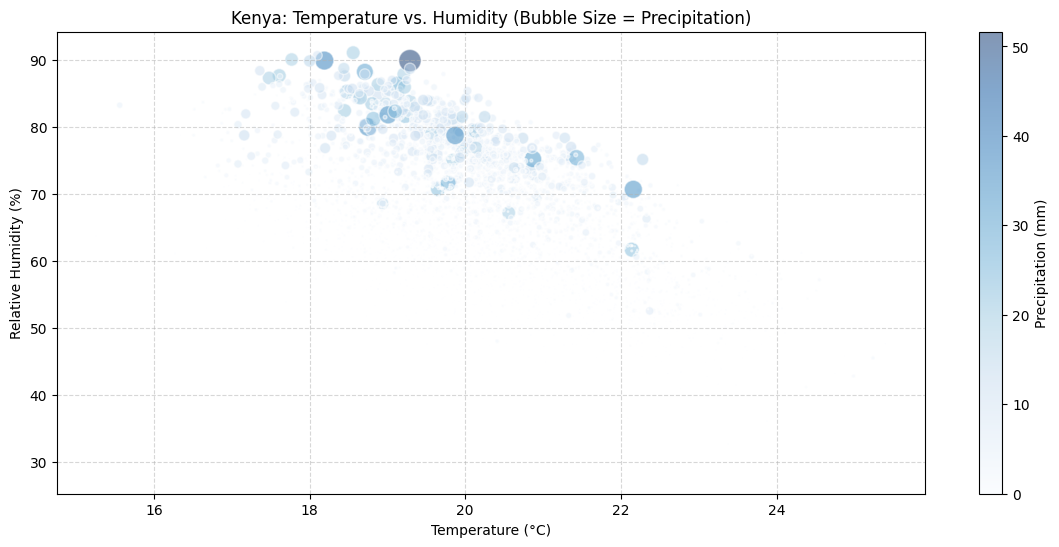

In [59]:
plt.figure(figsize=(14, 6))

scatter = plt.scatter(
    df_ken['T2M'], 
    df_ken['RH2M'], 
    s=df_ken['PRECTOTCORR'] * 5, 
    c=df_ken['PRECTOTCORR'], 
    cmap='Blues', 
    alpha=0.5, 
    edgecolors='w'
)

plt.colorbar(scatter, label='Precipitation (mm)')
plt.title("Kenya: Temperature vs. Humidity (Bubble Size = Precipitation)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Relative Humidity (%)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Summary: T2M vs. RH2M Bubble Chart (Size = Precipitation)**

-**Correlation**: Large bubbles (high rainfall) are concentrated in the **high humidity / moderate temperature** region.

-**Observations**: 
    - Rainfall events rarely occur at the highest temperature peaks or lowest humidity points.
    - The largest bubbles appear when temperatures are between 18°C and 23°C and relative humidity exceeds 75%, representing the peak of the rainy season.
    
-This chart confirms that significant precipitation in Kenya is driven by moisture saturation rather than extreme heat, with rainfall acting as a natural coolant for the local climate.

## Research & Learning References

NASA POWER Documentation: Understand the -999 sentinel value and parameter definitions (T2M vs T2M_MAX)

Pandas Documentation: Mastery of .dt accessors for Julian-to-Gregorian date conversion and ffill logic.

Seaborn Statistical Visualization: Best practices for log-scaled histograms and correlation heatmaps.